In [74]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets
from src.analisi.tools import *

In [75]:
%matplotlib widget
plt.close('all')

In [76]:
# selettore cartella
folder_selector = widgets.Dropdown( 
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('percolazione', 'old', 'lampadina_test_final', 'lampadina3_test', '…

In [91]:
#raccolgiamo le immagini per calcolare le intensità medie 

images, image_timestamps = load_images_from_folder(os.path.join(base_img_folder, folder_selector.value, 'images'))
images, image_timestamps = sort_images_and_timestamps(images, image_timestamps)

image_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in image_timestamps]
image_seconds = np.array(image_seconds)

image_trel = image_seconds - image_seconds[0]

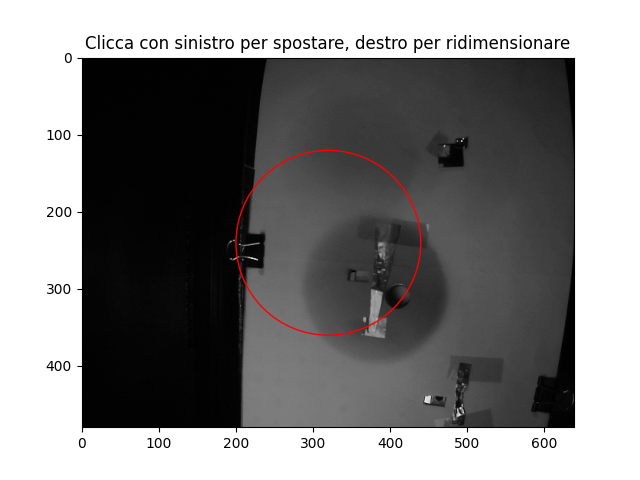

In [92]:
roi_select = RoiSelectorWidget(images[-1])

In [158]:
roi_center, roi_radius = roi_select.roi

In [159]:
def build_roi(im0, center_x, center_y, radius):
    
    h, w = im0.shape[:2]
    Y, X = np.ogrid[:h, :w]
    
    dist_from_center = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
    
    mask = dist_from_center <= radius
    
    return mask

In [160]:
def extract_roi_from_images(images, mask):
    return [image * mask for image in images]

In [161]:
def compute_mean(images, roi_mask):
    return [np.mean(image[roi_mask > 0]) for image in images]

In [162]:
def compute_diff_imgs(images, reference_image):
    return [reference_image - image for image in images]

In [163]:
reference_image = np.mean(images[:10], axis=0) if images else None
roi_mask = build_roi(reference_image, roi_center[0], roi_center[1], roi_radius)
roi_images = extract_roi_from_images(images, roi_mask)
reference_image_roi = extract_roi_from_images([reference_image], roi_mask)[0]
difference_images = compute_diff_imgs(roi_images, reference_image_roi)
mean_intensities = np.array(compute_mean(difference_images, roi_mask))

In [164]:
#window_size = 10

#images_smooth = moving_average_images(difference_images, window_size)
#mean_intensities = np.mean(images_smooth, axis=(1, 2))

In [165]:
print(mean_intensities[-1] - mean_intensities[0])

12.69709331973483


In [166]:
bilancia_timestamps, bilancia_thicknesses, bilancia_rates = load_bilancia_data(os.path.join(base_img_folder, folder_selector.value, "data", 'points.txt'))
bilancia_timestamps = np.array(bilancia_timestamps)
bilancia_trel = bilancia_timestamps - bilancia_timestamps[0]

In [167]:
print(image_seconds[0])
print(bilancia_timestamps[0])

1780496026.0
1780496033.8412511


In [168]:
t0 = bilancia_timestamps[0]
tf = bilancia_timestamps[-1]


time_mask = (image_seconds >= t0) & (image_seconds <= tf)
image_seconds_masked = image_seconds[time_mask]
mean_intensities_masked = mean_intensities[time_mask]

In [169]:
bilancia_trel = bilancia_timestamps - t0
image_trel = image_seconds_masked - t0

In [170]:
interpolated_thicknesses = np.interp(bilancia_trel, image_trel, mean_intensities_masked)

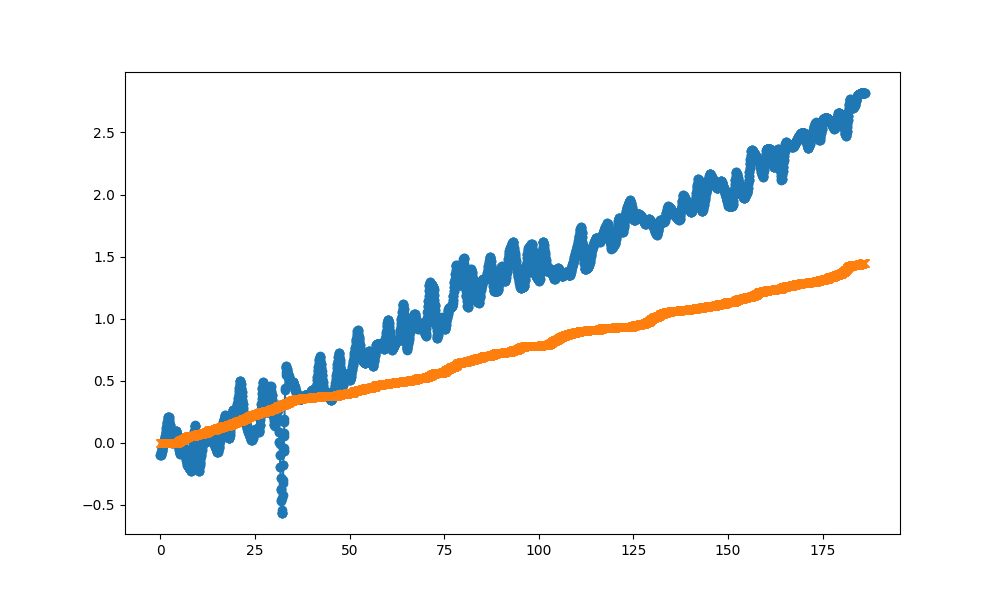

In [171]:
plt.figure(figsize=(10, 6))

plt.plot(bilancia_trel, interpolated_thicknesses, label='Intensità media (ROI)', marker='o')
plt.plot(bilancia_trel, bilancia_thicknesses, label='Spessore bilancia', marker='x')

plt.show()

In [172]:

m, q = np.polyfit(interpolated_thicknesses, bilancia_thicknesses, 1)
print(f"Coefficiente angolare: {m}, intercetta: {q}")

Coefficiente angolare: 0.48365414564407117, intercetta: 0.10418670168734395


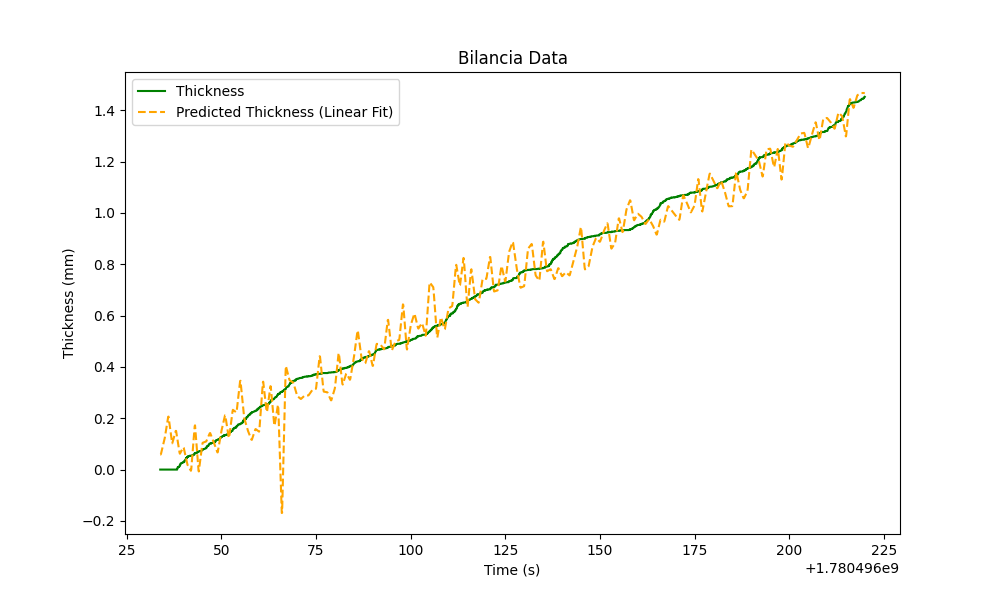

In [173]:
plt.figure(figsize=(10, 6))

plt.plot(bilancia_timestamps, bilancia_thicknesses, label='Thickness', color='green')

predicted_thicknesses = m * interpolated_thicknesses + q

plt.plot(bilancia_timestamps, predicted_thicknesses, label='Predicted Thickness (Linear Fit)', color='orange', linestyle='--')

plt.xlabel('Time (s)')
plt.ylabel('Thickness (mm)')
plt.title('Bilancia Data')
plt.legend()
plt.show()

In [175]:
print("time passed", bilancia_timestamps[-1] - bilancia_timestamps[0])
print("bilancia_thicknesses", bilancia_thicknesses[-1] - bilancia_thicknesses[0])
print("average rate", (bilancia_thicknesses[-1] - bilancia_thicknesses[0]) / (bilancia_timestamps[-1] - bilancia_timestamps[0]))

time passed 186.11908650398254
bilancia_thicknesses 1.452
average rate 0.00780145673006476


In [189]:
avg_rate = (4.5- 0) / (17*60)
avg_rate_min = avg_rate * 60

print(f"Average deposition rate: {avg_rate:.4f} nm/s")
print(f"Average deposition rate: {avg_rate_min:.4f} nm/min")

Average deposition rate: 0.0044 nm/s
Average deposition rate: 0.2647 nm/min


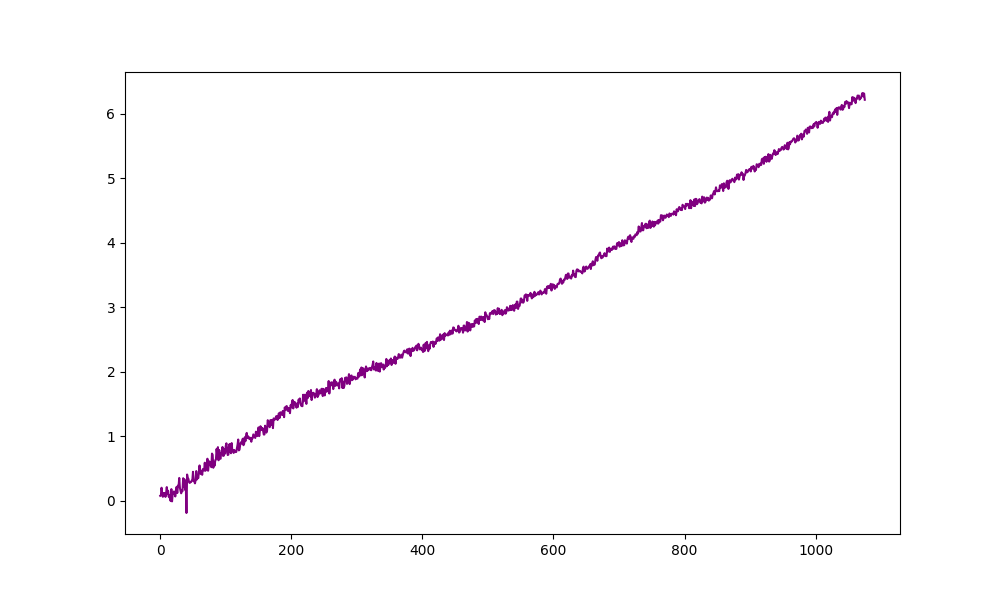

In [177]:
all_thicknesses = m * mean_intensities + q

plt.figure(figsize=(10, 6))

plt.plot(all_thicknesses, label='Predicted Thickness (All Data)', color='purple')
plt.show()

mean_rate 0.026546604783728753


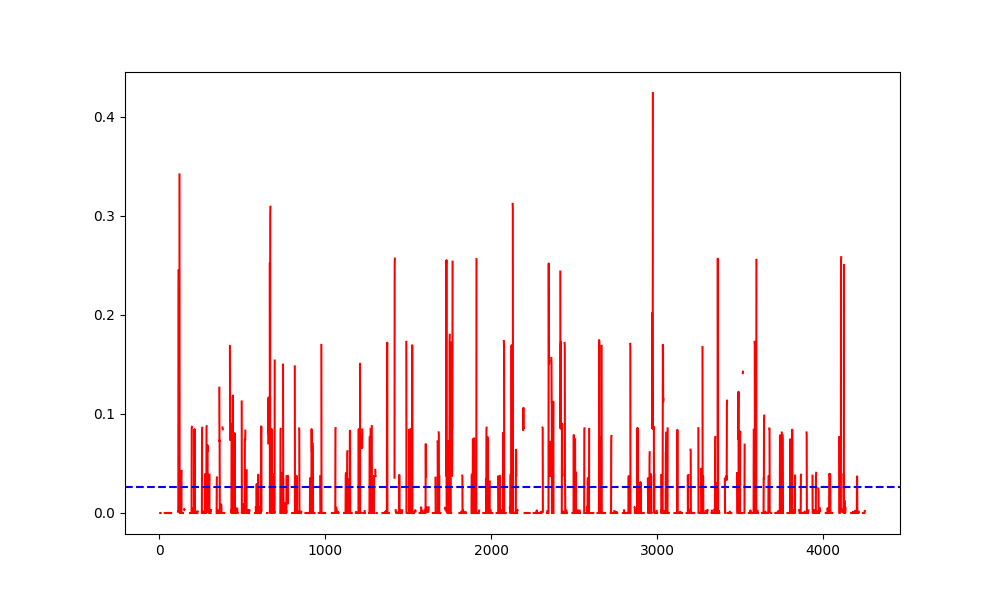

In [187]:
plt.figure(figsize=(10, 6))

rates = np.gradient(bilancia_thicknesses, bilancia_timestamps)

plt.plot(rates, label='Bilancia Rates', color='red')

mean_rate = np.mean(rates[rates >= 0])  # Consider only positive rates for mean calculation
plt.axhline(mean_rate, color='blue', linestyle='--', label=f'Mean Rate: {mean_rate:.2f} mm/s')
print("mean_rate", mean_rate)  # Convert to mm/s


plt.show()